In [1]:
import os
os.chdir('..')
print(os.getcwd())
print(os.listdir('data/raw/'))

/Users/abinesh/uni/gutgroove
['99_q.csv', '79_c.csv', '56_c.wav', '292_c.csv', '13_c.wav', '141_c.wav', '104_c.wav', '6_b.csv', '335_a.csv', '90_e.wav', '28_e.wav', '42_e.csv', '64_f.csv', '193_c.csv', '21_f.csv', '240_c.wav', '205_c.wav', '8_m.csv', '84_c.csv', '64_q.csv', '1_n.wav', '110_e.csv', '21_q.csv', '72_b.wav', '37_b.wav', '18_b.csv', '11_a.wav', '290_a.csv', '54_a.wav', '106_a.wav', '129_a.csv', '143_a.wav', '372_c.csv', '337_c.csv', '318_c.wav', '40_g.csv', '30_n.csv', '23_d.csv', '191_a.csv', '66_d.csv', '49_d.wav', '134_d.csv', '228_a.csv', '86_a.csv', '207_a.wav', '171_d.csv', '242_a.wav', '17_g.wav', '22_n.wav', '38_g.csv', '2_q.csv', '74_d.wav', '183_a.wav', '31_d.wav', '163_d.wav', '250_a.csv', '94_a.wav', '2_f.csv', '126_d.wav', '215_a.csv', '109_d.csv', '25_b.csv', '60_b.csv', '408_c.wav', '46_a.csv', '69_a.wav', '19_h.wav', '282_a.wav', '151_a.csv', '114_a.csv', '5_j.wav', '89_d.wav', '325_c.wav', '360_c.wav', '0_s.csv', '50_e.wav', '15_e.wav', '33_f.wav', '181_c.w

Sample rate: 44100 Hz
Duration: 2.00s


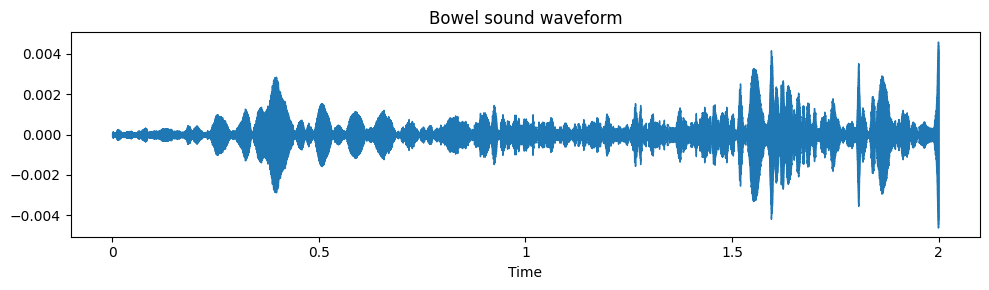

In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

filepath = "data/raw/378_c.wav"

y, sr = librosa.load(filepath, sr=None)
print(f"Sample rate: {sr} Hz")
print(f"Duration: {len(y)/sr:.2f}s")

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Bowel sound waveform")
plt.tight_layout()
plt.show()

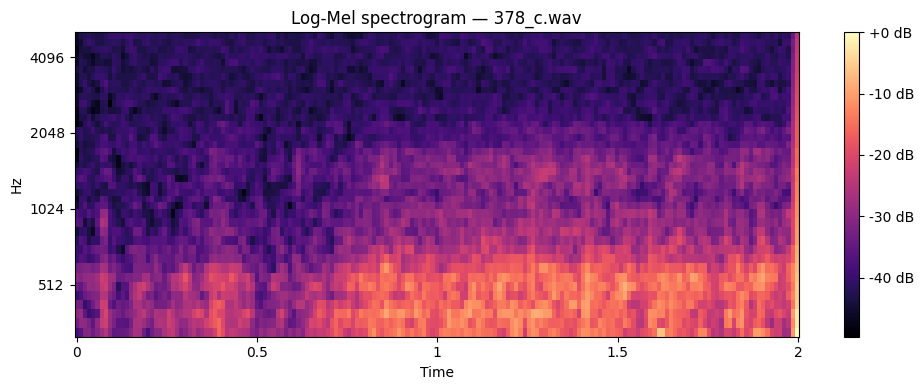

Spectrogram shape: (40, 173)


In [3]:
import numpy as np

# generate mel spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40, fmin=200, fmax=5000)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', fmin=200, fmax=5000)
plt.colorbar(format='%+2.0f dB')
plt.title("Log-Mel spectrogram — 378_c.wav")
plt.tight_layout()
plt.show()

print(f"Spectrogram shape: {S_db.shape}")  # should be (40, something)

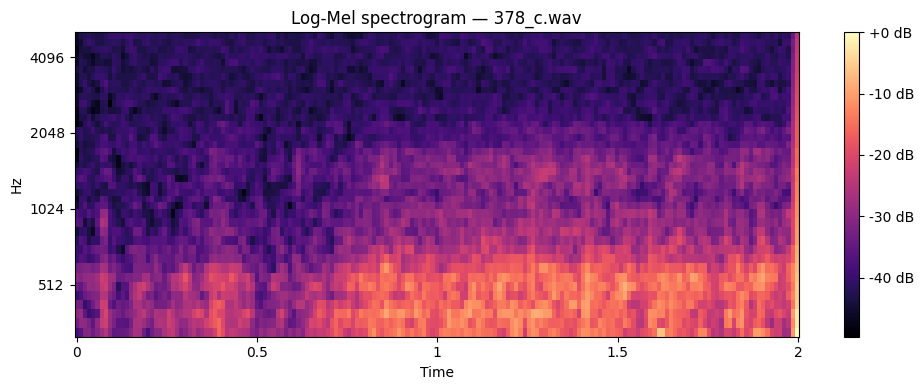

Spectrogram shape: (40, 173)


In [3]:
import numpy as np

# generate mel spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40, fmin=200, fmax=5000)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', fmin=200, fmax=5000)
plt.colorbar(format='%+2.0f dB')
plt.title("Log-Mel spectrogram — 378_c.wav")
plt.tight_layout()
plt.show()

print(f"Spectrogram shape: {S_db.shape}")  # should be (40, something)

In [4]:
import pandas as pd

label_path = "data/raw/378_c.csv"
df = pd.read_csv(label_path)
print(df.head(20))
print(df.columns.tolist())

      start       end        fmin         fmax category
0  1.253515  1.270930  256.410278  1652.421631        s
1  1.401542  1.426213  256.410278   883.190857        s
2  1.604717  1.629388  119.658119   319.088318        s
3  1.789025  1.822404  102.564102   313.390320        s
4  1.984943  2.019773   91.168091   307.692322        s
['start', 'end', 'fmin', 'fmax', 'category']


In [5]:
import os

# to look at what label types exist across the whole dataset
categories = []
for fname in os.listdir("data/raw/"):
    if fname.endswith(".csv") and fname != "files.csv":
        try:
            df = pd.read_csv(f"data/raw/{fname}")
            if 'category' in df.columns:
                categories.extend(df['category'].dropna().tolist())
        except:
            pass

from collections import Counter
print(Counter(categories))

Counter({'s': 3439, 'bc': 103, 'b': 100, 'a': 34, 'm': 20, 'd': 2, 'o': 1})


In [6]:
import os
import pandas as pd
from collections import defaultdict

data = []

for fname in os.listdir("data/raw/"):
    if not fname.endswith(".wav"):
        continue
    
    wav_path = f"data/raw/{fname}"
    csv_path = wav_path.replace(".wav", ".csv")
    
    if not os.path.exists(csv_path):
        label = "silence"
    else:
        try:
            df = pd.read_csv(csv_path)
            has_event = df['category'].dropna().shape[0] > 0
            label = "sound" if has_event else "silence"
        except:
            label = "silence"
    
    data.append({"file": wav_path, "label": label})

df_dataset = pd.DataFrame(data)
print(df_dataset['label'].value_counts())
print(f"\nTotal clips: {len(df_dataset)}")

label
silence    1016
sound       590
Name: count, dtype: int64

Total clips: 1606


In [7]:
import numpy as np
import librosa
import os

os.makedirs("data/spectrograms", exist_ok=True)

failed = []

for i, row in df_dataset.iterrows():
    try:
        y, sr = librosa.load(row['file'], sr=None)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40, fmin=200, fmax=5000)
        S_db = librosa.power_to_db(S, ref=np.max)
        
        fname = os.path.basename(row['file']).replace(".wav", ".npy")
        np.save(f"data/spectrograms/{fname}", S_db)
    except Exception as e:
        failed.append((row['file'], str(e)))
    
    if i % 100 == 0:
        print(f"{i}/1606 done...")

print(f"Done. Saved {len(df_dataset) - len(failed)} spectrograms.")
print(f"Failed: {len(failed)}")

0/1606 done...
100/1606 done...
200/1606 done...
300/1606 done...
400/1606 done...
500/1606 done...
600/1606 done...
700/1606 done...
800/1606 done...
900/1606 done...
1000/1606 done...
1100/1606 done...
1200/1606 done...
1300/1606 done...
1400/1606 done...
1500/1606 done...
1600/1606 done...
Done. Saved 1606 spectrograms.
Failed: 0


In [8]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

# load all spectrograms and labels
X = []
y = []

for _, row in df_dataset.iterrows():
    fname = os.path.basename(row['file']).replace(".wav", ".npy")
    spec = np.load(f"data/spectrograms/{fname}")
    X.append(spec)
    y.append(1 if row['label'] == "sound" else 0)

X = np.array(X)
y = np.array(y)

# CNN expects shape (samples, height, width, channels)
X = X[..., np.newaxis]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}, sounds: {y.sum()}, silences: {(y==0).sum()}")

# split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

X shape: (1606, 40, 173, 1)
y shape: (1606,), sounds: 590, silences: 1016
Train: 1284, Test: 322


In [9]:
# build the CNN
model = keras.Sequential([
    keras.layers.Input(shape=(40, 173, 1)),
    
    keras.layers.Conv2D(16, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 173, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 86, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 86, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 43, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 21, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6720)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       430,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 453,505 (1.73 MB)

 Trainable params: 453,505 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.6005 - loss: 1.4414 - val_accuracy: 0.6335 - val_loss: 0.6584
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.6269 - loss: 0.6635 - val_accuracy: 0.6335 - val_loss: 0.6586
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.6324 - loss: 0.6495 - val_accuracy: 0.6335 - val_loss: 0.6369
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.6324 - loss: 0.6150 - val_accuracy: 0.6335 - val_loss: 0.5780
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.6324 - loss: 0.5765 - val_accuracy: 0.6335 - val_loss: 0.5300
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.6316 - loss: 0.5228 - val_accuracy: 0.6335 - val_loss: 0.4688
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6324 - loss: 0.4819 - val_accuracy: 0.6335 - val_loss: 0.4738
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.7960 - loss: 0.4169 - val_accuracy: 0.8012 - v

Model saved.


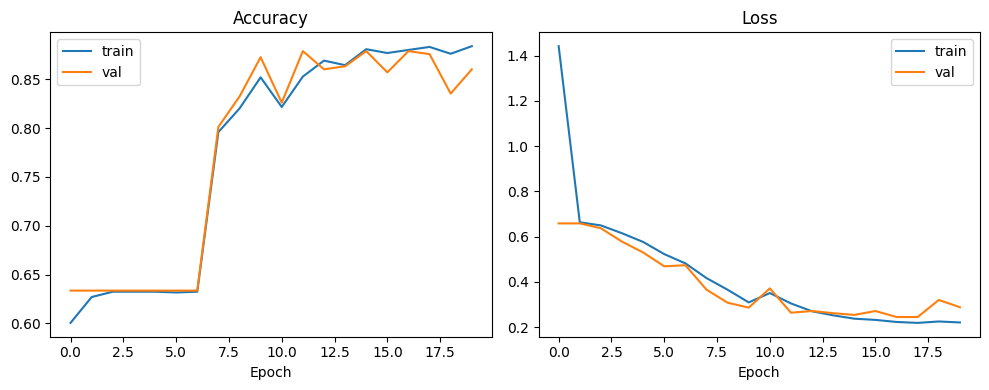

In [11]:
# save model
os.makedirs("models", exist_ok=True)
model.save("models/best_model.keras")
print("Model saved.")

# plot training curves
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# predict on a new audio file
def predict_ir(filepath, model, threshold=0.5):
    y, sr = librosa.load(filepath, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40, fmin=200, fmax=5000)
    S_db = librosa.power_to_db(S, ref=np.max)
    S_db = S_db[np.newaxis, ..., np.newaxis]  # add batch + channel dims
    
    prob = model.predict(S_db, verbose=0)[0][0]
    label = "sound" if prob > threshold else "silence"
    return {"file": filepath, "probability": round(float(prob), 3), "label": label}

# test on a few files
test_files = df_dataset.sample(5, random_state=1)['file'].tolist()

for f in test_files:
    result = predict_ir(f, model)
    actual = df_dataset[df_dataset['file'] == f]['label'].values[0]
    print(f"{os.path.basename(f):20s} → {result['label']:8s} (p={result['probability']}) | actual: {actual}")

115_b.wav            → sound    (p=0.661) | actual: silence
175_a.wav            → silence  (p=0.0) | actual: silence
30_d.wav             → silence  (p=0.0) | actual: silence
363_c.wav            → sound    (p=0.907) | actual: sound
0_j.wav              → sound    (p=0.719) | actual: sound


In [13]:
def compute_ir_score(audio_folder, model, n_files=30):
    """
    Simulate 1 minute of recording using 30 x 2s clips.
    Returns Intestinal Rate = detected sound events per minute.
    """
    wav_files = [f for f in os.listdir(audio_folder) if f.endswith(".wav")]
    sample = wav_files[:n_files]  # take first 30 = ~1 minute
    
    events = 0
    for fname in sample:
        result = predict_ir(f"{audio_folder}/{fname}", model)
        if result['label'] == "sound":
            events += 1
    
    ir = events  # events per minute
    print(f"Clips analysed: {n_files}")
    print(f"Sound events detected: {events}")
    print(f"Intestinal Rate (IR): {ir} events/min")
    print(f"Status: {'normal' if 5 <= ir <= 30 else 'abnormal'}")
    return ir

compute_ir_score("data/raw", model)

Clips analysed: 30
Sound events detected: 10
Intestinal Rate (IR): 10 events/min
Status: normal


10

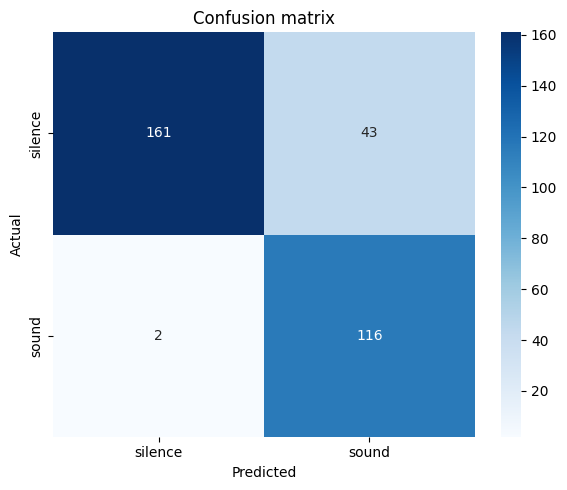

              precision    recall  f1-score   support

     silence       0.99      0.79      0.88       204
       sound       0.73      0.98      0.84       118

    accuracy                           0.86       322
   macro avg       0.86      0.89      0.86       322
weighted avg       0.89      0.86      0.86       322



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# run model on full test set
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['silence', 'sound'],
            yticklabels=['silence', 'sound'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png')
plt.show()

print(classification_report(y_test, y_pred, target_names=['silence', 'sound']))

In [15]:
def rolling_ir(audio_files, model, window_minutes=1):
    """
    Takes a list of 2s wav files in chronological order.
    Returns IR score per minute window.
    """
    clips_per_minute = 30  # 30 x 2s = 60s
    results = []
    
    for i in range(0, len(audio_files), clips_per_minute):
        window = audio_files[i:i + clips_per_minute]
        if len(window) < clips_per_minute:
            break
        
        events = 0
        for f in window:
            r = predict_ir(f, model)
            if r['label'] == 'sound':
                events += 1
        
        minute = (i // clips_per_minute) + 1
        status = 'normal' if 5 <= events <= 30 else 'abnormal'
        results.append({'minute': minute, 'ir': events, 'status': status})
        print(f"Minute {minute}: IR = {events} events/min — {status}")
    
    return results

# test with first 90 files = 3 minutes of simulated data
test_files = df_dataset['file'].tolist()[:90]
ir_timeline = rolling_ir(test_files, model)

Minute 1: IR = 10 events/min — normal
Minute 2: IR = 16 events/min — normal
Minute 3: IR = 17 events/min — normal


In [16]:
# to create src/predict.py
import os
os.makedirs("src", exist_ok=True)

code = '''import numpy as np
import librosa
import tensorflow as tf

def load_model(model_path="models/best_model.keras"):
    return tf.keras.models.load_model(model_path)

def predict_ir(filepath, model, threshold=0.5):
    y, sr = librosa.load(filepath, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40, fmin=200, fmax=5000)
    S_db = librosa.power_to_db(S, ref=np.max)
    S_db = S_db[np.newaxis, ..., np.newaxis]
    prob = model.predict(S_db, verbose=0)[0][0]
    label = "sound" if prob > threshold else "silence"
    return {"file": filepath, "probability": round(float(prob), 3), "label": label}

def rolling_ir(audio_files, model, clips_per_minute=30):
    results = []
    for i in range(0, len(audio_files), clips_per_minute):
        window = audio_files[i:i + clips_per_minute]
        if len(window) < clips_per_minute:
            break
        events = sum(1 for f in window if predict_ir(f, model)["label"] == "sound")
        minute = (i // clips_per_minute) + 1
        status = "normal" if 5 <= events <= 30 else "abnormal"
        results.append({"minute": minute, "ir": events, "status": status})
    return results
'''

with open("src/predict.py", "w") as f:
    f.write(code)

print("src/predict.py written.")

src/predict.py written.


In [17]:
# normalize each spectrogram to zero mean unit variance
X_mean = X.mean()
X_std = X.std()
X_normalized = (X - X_mean) / X_std

print(f"Before: min={X.min():.2f}, max={X.max():.2f}")
print(f"After: min={X_normalized.min():.2f}, max={X_normalized.max():.2f}")

Before: min=-80.00, max=0.00
After: min=-3.21, max=3.07


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42, stratify=y)

np.save("models/X_mean.npy", X_mean)
np.save("models/X_std.npy", X_std)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print("Saved normalization parameters.")

Train: 1284, Test: 322
Saved normalization parameters.


In [19]:
model2 = keras.Sequential([
    keras.layers.Input(shape=(40, 173, 1)),
    
    keras.layers.Conv2D(16, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history2 = model2.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.6184 - loss: 0.6623 - val_accuracy: 0.6335 - val_loss: 0.6313
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6737 - loss: 0.5923 - val_accuracy: 0.7516 - val_loss: 0.4953
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7555 - loss: 0.4614 - val_accuracy: 0.8199 - val_loss: 0.4110
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.8217 - loss: 0.3670 - val_accuracy: 0.8261 - val_loss: 0.3382
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.8419 - loss: 0.3229 - val_accuracy: 0.8230 - val_loss: 0.3220
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.8466 - loss: 0.2896 - val_accuracy: 0.8447 - val_loss: 0.3142
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.8621 - loss: 0.2546 - val_accuracy: 0.7950 - val_loss: 0.3466
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.8808 - loss: 0.2439 - val_accuracy: 0.8261 - v

In [20]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "models/best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model3 = keras.Sequential([
    keras.layers.Input(shape=(40, 173, 1)),
    keras.layers.Conv2D(16, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history3 = model3.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint, earlystop]
)

Epoch 1/50
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5925 - loss: 0.6764
Epoch 1: val_accuracy improved from None to 0.67391, saving model to models/best_model.keras

Epoch 1: finished saving model to models/best_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.6254 - loss: 0.6498 - val_accuracy: 0.6739 - val_loss: 0.5886
Epoch 2/50
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6505 - loss: 0.5663
Epoch 2: val_accuracy improved from 0.67391 to 0.71118, saving model to models/best_model.keras

Epoch 2: finished saving model to models/best_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.6807 - loss: 0.5362 - val_accuracy: 0.7112 - val_loss: 0.5128
Epoch 3/50
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7285 - loss: 0.4846
Epoch 3: val_accuracy improved from 0.71118 to 0.79814, saving model to models/best_model.keras

Epoch 3: finished saving model to models/best_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy:

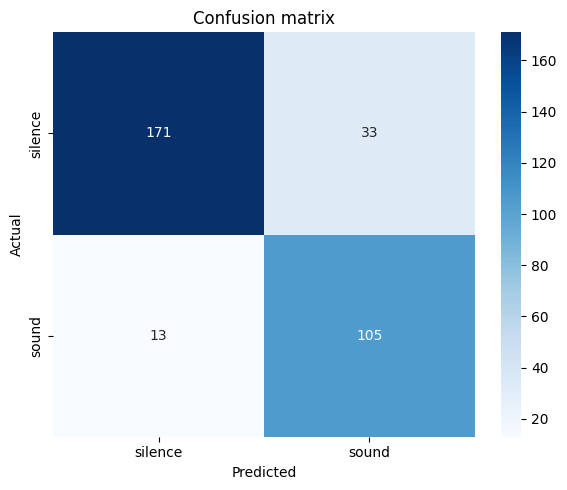

              precision    recall  f1-score   support

     silence       0.93      0.84      0.88       204
       sound       0.76      0.89      0.82       118

    accuracy                           0.86       322
   macro avg       0.85      0.86      0.85       322
weighted avg       0.87      0.86      0.86       322



In [21]:
y_pred_prob = model3.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['silence', 'sound'],
            yticklabels=['silence', 'sound'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png')
plt.show()

print(classification_report(y_test, y_pred, target_names=['silence', 'sound']))

In [29]:
# corrected predict function using normalization
X_mean = np.load("models/X_mean.npy")
X_std = np.load("models/X_std.npy")

def predict_ir(filepath, model, threshold=0.5):
    y, sr = librosa.load(filepath, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40, fmin=200, fmax=5000)
    S_db = librosa.power_to_db(S, ref=np.max)
    S_normalized = (S_db - X_mean) / X_std
    S_input = S_normalized[np.newaxis, ..., np.newaxis]
    prob = model.predict(S_input, verbose=0)[0][0]
    label = "sound" if prob > threshold else "silence"
    return {"file": filepath, "probability": round(float(prob), 3), "label": label}

# test it
result = predict_ir("data/raw/378_c.wav", model3)
print(result)

{'file': 'data/raw/378_c.wav', 'probability': 0.86, 'label': 'sound'}


In [30]:
test_files = df_dataset['file'].tolist()[:90]
ir_timeline = rolling_ir(test_files, model3)

Minute 1: IR = 11 events/min — normal
Minute 2: IR = 13 events/min — normal
Minute 3: IR = 16 events/min — normal


In [31]:
code = '''import numpy as np
import librosa
import tensorflow as tf
import os

def load_model(model_path="models/best_model.keras"):
    return tf.keras.models.load_model(model_path)

def load_norm_params(mean_path="models/X_mean.npy", std_path="models/X_std.npy"):
    X_mean = np.load(mean_path)
    X_std = np.load(std_path)
    return X_mean, X_std

def predict_ir(filepath, model, X_mean, X_std, threshold=0.5):
    y, sr = librosa.load(filepath, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40, fmin=200, fmax=5000)
    S_db = librosa.power_to_db(S, ref=np.max)
    S_normalized = (S_db - X_mean) / X_std
    S_input = S_normalized[np.newaxis, ..., np.newaxis]
    prob = model.predict(S_input, verbose=0)[0][0]
    label = "sound" if prob > threshold else "silence"
    return {"file": filepath, "probability": round(float(prob), 3), "label": label}

def rolling_ir(audio_files, model, X_mean, X_std, clips_per_minute=30):
    results = []
    for i in range(0, len(audio_files), clips_per_minute):
        window = audio_files[i:i + clips_per_minute]
        if len(window) < clips_per_minute:
            break
        events = sum(1 for f in window if predict_ir(f, model, X_mean, X_std)["label"] == "sound")
        minute = (i // clips_per_minute) + 1
        status = "normal" if 5 <= events <= 30 else "abnormal"
        results.append({"minute": minute, "ir": events, "status": status})
    return results
'''

with open("src/predict.py", "w") as f:
    f.write(code)

print("src/predict.py updated.")

src/predict.py updated.
